In [35]:
from joblib import load

import pandas as pd
import numpy as np

from pyADA import Smetrics

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from sklearn.model_selection import train_test_split
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold

from math import sqrt
from tqdm import tqdm

# Gibbs energy validations

### External validation
- Note: To run, unzip models that are in .tar.gz format

In [78]:
import pickle
xgb = 'models_gibbs/XGB_gibbs.sav'
xgb = pickle.load(open(xgb,'rb'))

rf = 'models_gibbs/RF_gibbs.sav'
rf = pickle.load(open(rf,'rb'))

mlp = 'models_gibbs/MLP_gibbs.sav'
mlp = pickle.load(open(mlp,'rb'))

In [20]:
dfworkfull = pd.read_pickle('DFWork_ECFP4K.pkl',compression='zip')
dfworkfull

,GibbsEnergy,Smiles,GibbsEnergy_scaledByMaxValue,MolWeight,0,1,2,3,4,5,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,-1955.779399,CN(C)C(=O)NC1CCC(CCNCCNc2cccc(Cl)c2Cl)CC1,0.687816,400.179667,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-1162.625402,CNCCC(O)(Oc1ccc(C(F)(F)F)cc1)c1ccccc1,0.400579,325.128963,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-56.497083,N,0.000000,17.026549,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-114.440369,C=O,0.020984,30.010565,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-2324.340178,O=CC1=C(C(=O)O)N2C(=O)C(NC(=O)C(=NOCC(=O)O)c3c...,0.821288,468.999819,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14202,-1882.536646,CCOc1cc(C(CS(C)(=O)=O)N2C(=O)c3cccc([N+](=O)[O...,0.661291,448.094037,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14203,-1873.541964,CN1C=CN(CCCN(c2cc(Cl)ccc2O)c2ccccc2S)CC1,0.658034,389.132861,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14204,-1681.019809,CCc1cc2c(cc1N1CCC(N3C=COCC3)CC1)C(C)(C)C13NC45...,0.588313,512.242356,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14205,-1864.405535,CCCCc1nc(Cl)c(C(=O)O)n1C(O)c1ccc(-c2ccccc2-c2n...,0.654725,452.136366,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
xi = dfworkfull.iloc[:, 4:].values
y = dfworkfull.iloc[:,2].values
y

xi_train, xi_test, y_train, y_test = train_test_split(xi, y, test_size=0.2, random_state=67857)
print('train = {} test = {}'.format(len(xi_train), len(xi_test)))

train = 11365 test = 2842


In [58]:
sm = Smetrics()

In [65]:
y_pred_xgb = xgb.predict(xi_test)
q2ext_xgb = sm.Q2ext(y_pred=y_pred_xgb, y_train=y_train, y_true=y_test)
R2ext_xgb = xgb.score(xi_train, y_train)
r2_ext_xgb = stats.pearsonr(y_pred_xgb, y_test)
rmse_xgb = sm.roots_mean_square_error(y_pred=y_pred_xgb, y_true=y_test)
print('q2ext = {}, R2ext {},r2ext = {}, rmse = {}'.format(q2ext_xgb, R2ext_xgb ,r2_ext_xgb, rmse_xgb))

q2ext = 0.9653110420828157, R2ext 0.9975337960834563,r2ext = PearsonRResult(statistic=0.9825544045911352, pvalue=0.0), rmse = 0.03528387456278356


In [66]:
y_pred_rf = rf.predict(xi_test)
q2ext_rf = sm.Q2ext(y_pred=y_pred_rf, y_train=y_train, y_true=y_test)
R2ext_rf = rf.score(xi_train, y_train)
r2_ext_rf = stats.pearsonr(y_pred_rf, y_test)
rmse_rf = sm.roots_mean_square_error(y_pred=y_pred_rf, y_true=y_test)

print('q2ext = {}, R2ext {},r2ext = {}, rmse = {}'.format(q2ext_rf, R2ext_rf ,r2_ext_rf, rmse_rf))

q2ext = 0.9360523233073668, R2ext 0.9879870551453602,r2ext = PearsonRResult(statistic=0.9685207771737163, pvalue=0.0), rmse = 0.04790634392329219


In [67]:
y_pred_mlp = mlp.predict(xi_test)
q2ext_mlp = sm.Q2ext(y_pred=y_pred_mlp, y_train=y_train, y_true=y_test)
R2ext_mlp = mlp.score(xi_train, y_train)
r2_ext_mlp = stats.pearsonr(y_pred_mlp, y_test)
rmse_mlp = sm.roots_mean_square_error(y_pred=y_pred_mlp, y_true=y_test)

print('q2ext = {}, R2ext {}, r2ext = {}, rmse = {}'.format(q2ext_mlp,R2ext_mlp,r2_ext_mlp, rmse_mlp))

q2ext = 0.9773123973631608, R2ext 0.9910630982583922, r2ext = PearsonRResult(statistic=0.9889796100113472, pvalue=0.0), rmse = 0.028534807445616085


#### Graphics

In [29]:
import numpy as np
dfxgb = pd.DataFrame(np.vstack((y_test,y_pred_xgb)).T,columns=['y_true','y_pred'])
dfrf = pd.DataFrame(np.vstack((y_test,y_pred_rf)).T,columns=['y_true','y_pred'])
dfmlp = pd.DataFrame(np.vstack((y_test,y_pred_mlp)).T,columns=['y_true','y_pred'])
dfmlp

,y_true,y_pred
0,0.438513,0.413246
1,0.617683,0.616511
2,0.298221,0.329169
3,0.438119,0.424270
4,0.374436,0.353829
...,...,...
2837,0.479152,0.499106
2838,0.347216,0.363927
2839,0.415476,0.414512
2840,0.738129,0.722508


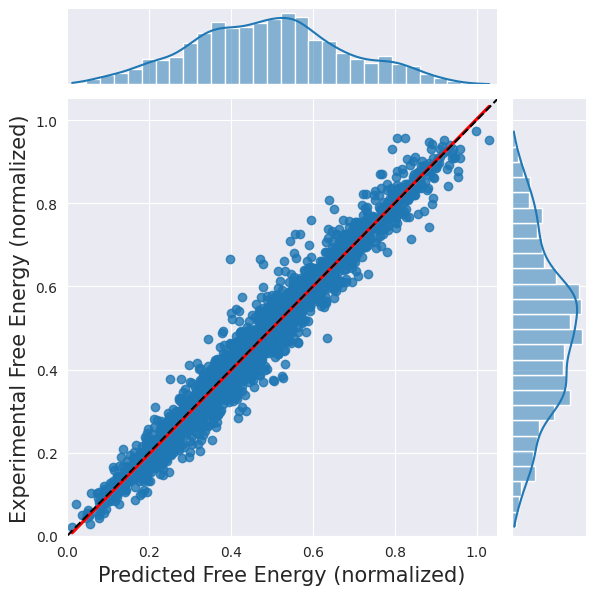

In [30]:
## XGB
sns.set_style('darkgrid')

sns_plot = sns.jointplot(x="y_pred", y="y_true", data=dfxgb, kind="reg",line_kws={"color": "red"})
plt.xlabel(r'Predicted Free Energy (normalized)', fontsize=15)
plt.ylabel(r'Experimental Free Energy (normalized)', fontsize=15)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.plot(np.arange(0,1.2,0.1), np.arange(0,1.2,0.1),
         linestyle='--',c='black', label='Experimental')
#plt.legend(loc='upper left')

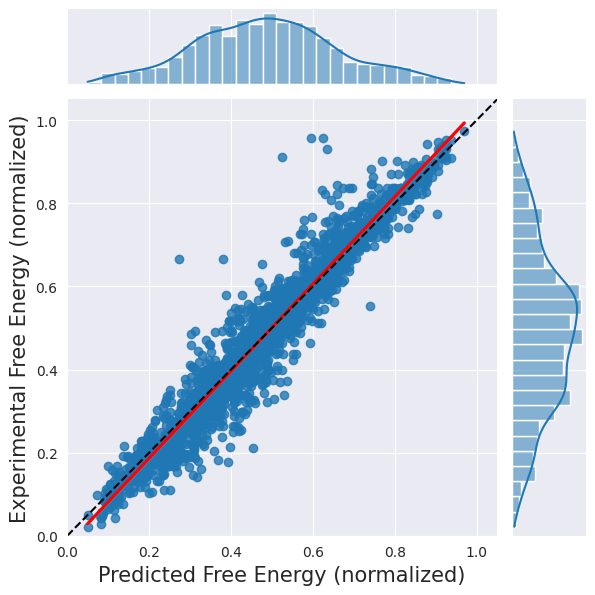

In [32]:
#Random forest

sns_plot = sns.jointplot(x="y_pred", y="y_true", data=dfrf, kind="reg",line_kws={"color": "red"})
plt.xlabel(r'Predicted Free Energy (normalized)', fontsize=15)
plt.ylabel(r'Experimental Free Energy (normalized)', fontsize=15)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.plot(np.arange(0,1.2,0.1), np.arange(0,1.2,0.1),
         linestyle='--',c='black', label='Experimental')
#plt.legend(loc='upper left')

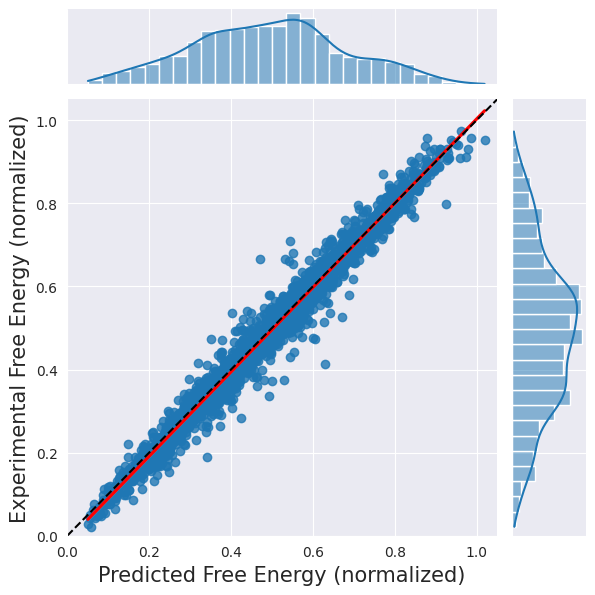

In [33]:
#MLP
sns_plot = sns.jointplot(x="y_pred", y="y_true", data=dfmlp, kind="reg",line_kws={"color": "red"})
plt.xlabel(r'Predicted Free Energy (normalized)', fontsize=15)
plt.ylabel(r'Experimental Free Energy (normalized)', fontsize=15)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.plot(np.arange(0,1.2,0.1), np.arange(0,1.2,0.1),
         linestyle='--',c='black', label='Experimental')
#plt.legend(loc='upper left')

### Crossvalidation

In [70]:
xi = xi_train
y = y_train
met = Smetrics()

skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
results_randomforest = []
results_xgb = []
results_mlp = []

rmse_randomforest = []
rmse_xgb = []
rmse_mlp = []

q2_randomforest = []
q2_xgb = []
q2_mlp = []

r2_pearson_rf = []
r2_pearson_xgb = []
r2_pearson_mlp = []

#criando uma matriz de 0 com mesmo numero de linhas que nossa matriz de dados
togetindexes = np.zeros(shape=(xi.shape[0], 1))

for index_train, index_test in tqdm(skfold.split(xi, togetindexes)):
    
    ## Random forest
    #rfreg.fit(xi[index_train], y[index_train])
    results_randomforest.append(rf.score(xi[index_train], y[index_train]))
    rmse_randomforest.append(sqrt(mean_squared_error(y[index_test],
                                                rf.predict(xi[index_test]))))
    q2_randomforest.append(met.Q2ext(y[index_test], rf.predict(xi[index_test]), y[index_train]))
    r2_pearson_rf.append(stats.pearsonr(rf.predict(xi[index_test]), y[index_test])[0])

    
    ## xgboost
    #xgb.fit(xi[index_train], y[index_train])
    results_xgb.append(xgb.score(xi[index_train], y[index_train]))
    rmse_xgb.append(sqrt(mean_squared_error(y[index_test],
                                                xgb.predict(xi[index_test]))))    
    q2_xgb.append(met.Q2ext(y[index_test], xgb.predict(xi[index_test]), y[index_train]))
    r2_pearson_xgb.append(stats.pearsonr(xgb.predict(xi[index_test]), y[index_test])[0])
           
    
    ## Neural Network
    #mlpreg.fit(xi[index_train], y[index_train])
    results_mlp.append(mlp.score(xi[index_train], y[index_train]))
    rmse_mlp.append(mean_squared_error(y[index_test], 
                                       mlp.predict(xi[index_test]))) 
    q2_mlp.append(met.Q2ext(y[index_test], mlp.predict(xi[index_test]), y[index_train]))
    r2_pearson_mlp.append(stats.pearsonr(mlp.predict(xi[index_test]), y[index_test])[0])

    

10it [00:14,  1.49s/it]


In [72]:
# R2
data2df = {'RandomForest':results_randomforest,
           'xgb':results_xgb, 
           'NeuralNetwork':results_mlp}

media = [np.array(results_randomforest).mean(), 
         np.array(results_xgb).mean(), 
         np.array(results_mlp).mean()]

std_r2 = [np.array(results_randomforest).std(ddof=1), 
         np.array(results_xgb).std(ddof=1), 
         np.array(results_mlp).std(ddof=1)]

df_validation = pd.DataFrame(data2df)
df_validation.loc['mean'] = media
df_validation.loc['std'] = std_r2

df_validation

,RandomForest,xgb,NeuralNetwork
0,0.987902,0.997563,0.991073
1,0.988157,0.997655,0.991187
2,0.987859,0.997512,0.991188
3,0.988084,0.997453,0.990986
4,0.988181,0.997496,0.991040
5,0.988168,0.997808,0.991172
6,0.987909,0.997425,0.990922
7,0.987762,0.997427,0.990955
8,0.987872,0.997503,0.991073
9,0.987975,0.997495,0.991035


In [53]:
# Intervalo de confiança 95% (t-student)
n = len(results_randomforest)
conf_int = stats.t.interval(confidence=0.95, df=n-1, loc=media, scale=std_r2/np.sqrt(n))
conf_int

(array([0.98787963, 0.99744936, 0.9909948 ]),
 array([0.98809425, 0.99761801, 0.99113108]))

In [54]:
# Q2
data2df = {'RandomForest':q2_randomforest,
           'xgb':q2_xgb, 
           'NeuralNetwork':q2_mlp}

media = [np.array(q2_randomforest).mean(), 
         np.array(q2_xgb).mean(), 
         np.array(q2_mlp).mean()]

std_q2 = [np.array(q2_randomforest).std(ddof=1), 
         np.array(q2_xgb).std(ddof=1), 
         np.array(q2_mlp).std(ddof=1)]

df_validation = pd.DataFrame(data2df)
df_validation.loc['mean'] = media
df_validation.loc['std'] = std_q2

df_validation

,RandomForest,xgb,NeuralNetwork
0,0.988747,0.997275,0.990971
1,0.986435,0.996426,0.989938
2,0.989114,0.997729,0.989967
3,0.987154,0.998234,0.991726
4,0.986278,0.997869,0.991266
5,0.986337,0.995034,0.990076
6,0.988682,0.998498,0.992316
7,0.990004,0.998486,0.992035
8,0.989059,0.997820,0.990979
9,0.988106,0.997904,0.991335


In [55]:
# Intervalo de confiança 95% (t-student)
n = len(q2_randomforest)
conf_int = stats.t.interval(confidence=0.95, df=n-1, loc=media, scale=std_q2/np.sqrt(n))
conf_int

(array([0.98702849, 0.99676451, 0.99045169]),
 array([0.98895451, 0.99829047, 0.99167015]))

In [73]:
# RMSE
data2df = {'RandomForest':rmse_randomforest,
           'xgb':rmse_xgb, 
           'NeuralNetwork':rmse_mlp}

media = [np.array(rmse_randomforest).mean(), 
         np.array(rmse_xgb).mean(), 
         np.array(rmse_mlp).mean()]

std_rmse = [np.array(rmse_randomforest).std(ddof=1), 
         np.array(rmse_xgb).std(ddof=1), 
         np.array(rmse_mlp).std(ddof=1)]

df_validation = pd.DataFrame(data2df)
df_validation.loc['mean'] = media
df_validation.loc['std'] = std_rmse

df_validation

,RandomForest,xgb,NeuralNetwork
0,0.020050,0.009866,0.000323
1,0.021840,0.011211,0.000354
2,0.019895,0.009088,0.000365
3,0.021808,0.008086,0.000306
4,0.022302,0.008789,0.000317
5,0.021956,0.013236,0.000350
6,0.020212,0.007362,0.000277
7,0.018920,0.007363,0.000285
8,0.019469,0.008690,0.000313
9,0.020122,0.008448,0.000295


In [74]:
# Intervalo de confiança 95% (t-student)
n = len(q2_randomforest)
conf_int = stats.t.interval(confidence=0.95, df=n-1, loc=media, scale=std_rmse/np.sqrt(n))
conf_int

(array([0.01979822, 0.00791264, 0.00029716]),
 array([0.02151649, 0.01051505, 0.00033969]))

In [75]:
# r2 pearson
# RMSE
data2df = {'RandomForest':r2_pearson_rf,
           'xgb':r2_pearson_xgb, 
           'NeuralNetwork':r2_pearson_mlp}

media = [np.array(r2_pearson_rf).mean(), 
         np.array(r2_pearson_xgb).mean(), 
         np.array(r2_pearson_mlp).mean()]

std_r2p = [np.array(r2_pearson_rf).std(ddof=1), 
         np.array(r2_pearson_xgb).std(ddof=1), 
         np.array(r2_pearson_mlp).std(ddof=1)]

df_validation = pd.DataFrame(data2df)
df_validation.loc['mean'] = media
df_validation.loc['std'] = std_r2p

df_validation

,RandomForest,xgb,NeuralNetwork
0,0.994843,0.998641,0.995715
1,0.993725,0.998223,0.995137
2,0.994974,0.998869,0.995329
3,0.994016,0.999116,0.996113
4,0.993658,0.998934,0.996024
5,0.993499,0.997515,0.995302
6,0.994751,0.999252,0.996515
7,0.995403,0.999255,0.996290
8,0.994851,0.998910,0.995842
9,0.994483,0.998953,0.995879


In [77]:
# Intervalo de confiança 95% (t-student)
n = len(r2_pearson_rf)
conf_int = stats.t.interval(confidence=0.95, df=n-1, loc=media, scale=std_r2p/np.sqrt(n))
conf_int

(array([0.99395381, 0.99838462, 0.99549268]),
 array([0.99488693, 0.99914879, 0.99613636]))

# Enthalpy models validation

In [79]:
import pickle
xgb = 'models_ent/XGB_Enthalpy.sav'
xgb = pickle.load(open(xgb,'rb'))

rf = 'models_ent/RF_Enthalpy.sav'
rf = pickle.load(open(rf,'rb'))

mlp = 'models_ent/MLP_Enthalpy.sav'
mlp = pickle.load(open(mlp,'rb'))

In [89]:
dfworkfull = pd.read_pickle('DFWork_ECFP4K_Enthalpie.pkl', compression='zip')
dfworkfull

,Enthalpie,Smiles,Enthalpie_scaledByMaxValue,MolWeight,0,1,2,3,4,5,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,-1955.688389,CN(C)C(=O)NC1CCC(CCNCCNc2cccc(Cl)c2Cl)CC1,0.687813,400.179667,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-1162.549975,CNCCC(O)(Oc1ccc(C(F)(F)F)cc1)c1ccccc1,0.400573,325.128963,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-56.474209,N,0.000000,17.026549,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-114.414906,C=O,0.020984,30.010565,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-2324.243274,O=CC1=C(C(=O)O)N2C(=O)C(NC(=O)C(=NOCC(=O)O)c3c...,0.821288,468.999819,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14202,-1882.444024,CCOc1cc(C(CS(C)(=O)=O)N2C(=O)c3cccc([N+](=O)[O...,0.661287,448.094037,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14203,-1873.460126,CN1C=CN(CCCN(c2cc(Cl)ccc2O)c2ccccc2S)CC1,0.658034,389.132861,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14204,-1680.921367,CCc1cc2c(cc1N1CCC(N3C=COCC3)CC1)C(C)(C)C13NC45...,0.588304,512.242356,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14205,-1864.313024,CCCCc1nc(Cl)c(C(=O)O)n1C(O)c1ccc(-c2ccccc2-c2n...,0.654721,452.136366,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [90]:
xi = dfworkfull.iloc[:, 4:].values
y = dfworkfull.iloc[:,2].values
y

xi_train, xi_test, y_train, y_test = train_test_split(xi, y, test_size=0.2, random_state=67857)
print('train = {} test = {}'.format(len(xi_train), len(xi_test)))

train = 11365 test = 2842


In [91]:
sm = Smetrics()

In [92]:
y_pred_xgb = xgb.predict(xi_test)
q2ext_xgb = sm.Q2ext(y_pred=y_pred_xgb, y_train=y_train, y_true=y_test)
R2ext_xgb = xgb.score(xi_train, y_train)
r2_ext_xgb = stats.pearsonr(y_pred_xgb, y_test)
rmse_xgb = sm.roots_mean_square_error(y_pred=y_pred_xgb, y_true=y_test)
print('q2ext = {}, R2ext {},r2ext = {}, rmse = {}'.format(q2ext_xgb, R2ext_xgb ,r2_ext_xgb, rmse_xgb))

q2ext = 0.9433180165912174, R2ext 0.9663094818071019,r2ext = PearsonRResult(statistic=0.9715716529160395, pvalue=0.0), rmse = 0.04510270590737631


In [93]:
y_pred_rf = rf.predict(xi_test)
q2ext_rf = sm.Q2ext(y_pred=y_pred_rf, y_train=y_train, y_true=y_test)
R2ext_rf = rf.score(xi_train, y_train)
r2_ext_rf = stats.pearsonr(y_pred_rf, y_test)
rmse_rf = sm.roots_mean_square_error(y_pred=y_pred_rf, y_true=y_test)

print('q2ext = {}, R2ext {},r2ext = {}, rmse = {}'.format(q2ext_rf, R2ext_rf ,r2_ext_rf, rmse_rf))

q2ext = 0.9363256898949243, R2ext 0.9879393793861488,r2ext = PearsonRResult(statistic=0.9686801835617744, pvalue=0.0), rmse = 0.04780377599509012


In [94]:
y_pred_mlp = mlp.predict(xi_test)
q2ext_mlp = sm.Q2ext(y_pred=y_pred_mlp, y_train=y_train, y_true=y_test)
R2ext_mlp = mlp.score(xi_train, y_train)
r2_ext_mlp = stats.pearsonr(y_pred_mlp, y_test)
rmse_mlp = sm.roots_mean_square_error(y_pred=y_pred_mlp, y_true=y_test)

print('q2ext = {}, R2ext {}, r2ext = {}, rmse = {}'.format(q2ext_mlp,R2ext_mlp,r2_ext_mlp, rmse_mlp))

q2ext = 0.9751468738001855, R2ext 0.9896529141488103, r2ext = PearsonRResult(statistic=0.9875767304591345, pvalue=0.0), rmse = 0.02986555509207384


#### Graphics

In [95]:
import numpy as np
dfxgb = pd.DataFrame(np.vstack((y_test,y_pred_xgb)).T,columns=['y_true','y_pred'])
dfrf = pd.DataFrame(np.vstack((y_test,y_pred_rf)).T,columns=['y_true','y_pred'])
dfmlp = pd.DataFrame(np.vstack((y_test,y_pred_mlp)).T,columns=['y_true','y_pred'])
dfmlp

,y_true,y_pred
0,0.438507,0.425624
1,0.617673,0.609953
2,0.298215,0.319837
3,0.438114,0.417495
4,0.374431,0.345571
...,...,...
2837,0.479151,0.474642
2838,0.347211,0.350695
2839,0.415472,0.443393
2840,0.738124,0.739833


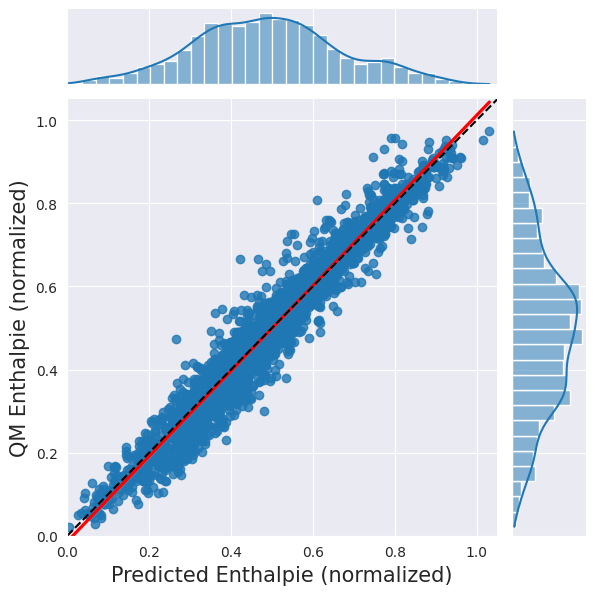

In [96]:

sns.set_style('darkgrid')

sns_plot = sns.jointplot(x="y_pred", y="y_true", data=dfxgb, kind="reg",line_kws={"color": "red"})
plt.xlabel(r'Predicted Enthalpie (normalized)', fontsize=15)
plt.ylabel(r'QM Enthalpie (normalized)', fontsize=15)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.plot(np.arange(0,1.2,0.1), np.arange(0,1.2,0.1),
         linestyle='--',c='black', label='Experimental')
#plt.legend(loc='upper left')

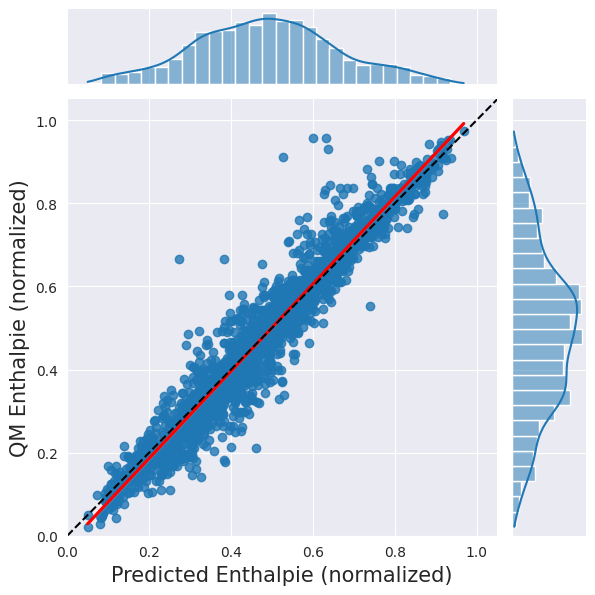

In [97]:
sns_plot = sns.jointplot(x="y_pred", y="y_true", data=dfrf, kind="reg",line_kws={"color": "red"})
plt.xlabel(r'Predicted Enthalpie (normalized)', fontsize=15)
plt.ylabel(r'QM Enthalpie (normalized)', fontsize=15)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.plot(np.arange(0,1.2,0.1), np.arange(0,1.2,0.1),
         linestyle='--',c='black', label='Experimental')
#plt.legend(loc='upper left')

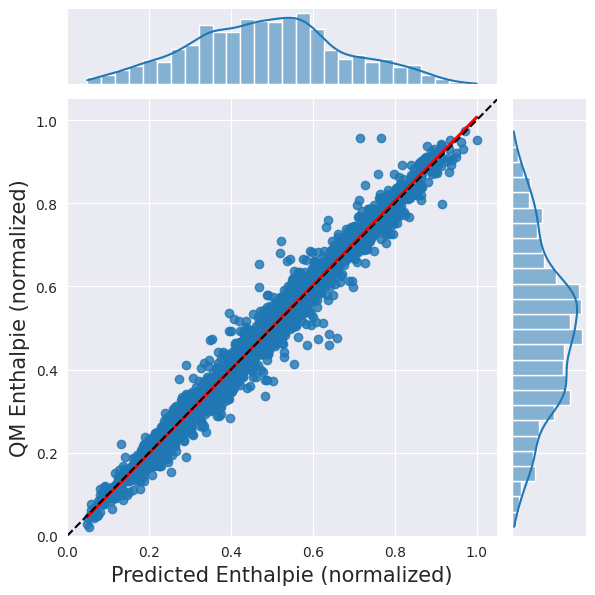

In [98]:
sns_plot = sns.jointplot(x="y_pred", y="y_true", data=dfmlp, kind="reg",line_kws={"color": "red"})
plt.xlabel(r'Predicted Enthalpie (normalized)', fontsize=15)
plt.ylabel(r'QM Enthalpie (normalized)', fontsize=15)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.plot(np.arange(0,1.2,0.1), np.arange(0,1.2,0.1),
         linestyle='--',c='black', label='Experimental')
#plt.legend(loc='upper left')

#### Crossvalidation

In [99]:
xi = xi_train
y = y_train
met = Smetrics()

skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
results_randomforest = []
results_xgb = []
results_mlp = []

rmse_randomforest = []
rmse_xgb = []
rmse_mlp = []

q2_randomforest = []
q2_xgb = []
q2_mlp = []

r2_pearson_rf = []
r2_pearson_xgb = []
r2_pearson_mlp = []

#criando uma matriz de 0 com mesmo numero de linhas que nossa matriz de dados
togetindexes = np.zeros(shape=(xi.shape[0], 1))

for index_train, index_test in tqdm(skfold.split(xi, togetindexes)):
    
    ## Random forest
    #rfreg.fit(xi[index_train], y[index_train])
    results_randomforest.append(rf.score(xi[index_train], y[index_train]))
    rmse_randomforest.append(sqrt(mean_squared_error(y[index_test],
                                                rf.predict(xi[index_test]))))
    q2_randomforest.append(met.Q2ext(y[index_test], rf.predict(xi[index_test]), y[index_train]))
    r2_pearson_rf.append(stats.pearsonr(rf.predict(xi[index_test]), y[index_test])[0])

    
    ## xgboost
    #xgb.fit(xi[index_train], y[index_train])
    results_xgb.append(xgb.score(xi[index_train], y[index_train]))
    rmse_xgb.append(sqrt(mean_squared_error(y[index_test],
                                                xgb.predict(xi[index_test]))))    
    q2_xgb.append(met.Q2ext(y[index_test], xgb.predict(xi[index_test]), y[index_train]))
    r2_pearson_xgb.append(stats.pearsonr(xgb.predict(xi[index_test]), y[index_test])[0])
           
    
    ## Neural Network
    #mlpreg.fit(xi[index_train], y[index_train])
    results_mlp.append(mlp.score(xi[index_train], y[index_train]))
    rmse_mlp.append(mean_squared_error(y[index_test], 
                                       mlp.predict(xi[index_test]))) 
    q2_mlp.append(met.Q2ext(y[index_test], mlp.predict(xi[index_test]), y[index_train]))
    r2_pearson_mlp.append(stats.pearsonr(mlp.predict(xi[index_test]), y[index_test])[0])

    

10it [00:13,  1.33s/it]


In [100]:
# R2
data2df = {'RandomForest':results_randomforest,
           'xgb':results_xgb, 
           'NeuralNetwork':results_mlp}

media = [np.array(results_randomforest).mean(), 
         np.array(results_xgb).mean(), 
         np.array(results_mlp).mean()]

std_r2 = [np.array(results_randomforest).std(ddof=1), 
         np.array(results_xgb).std(ddof=1), 
         np.array(results_mlp).std(ddof=1)]

df_validation = pd.DataFrame(data2df)
df_validation.loc['mean'] = media
df_validation.loc['std'] = std_r2

df_validation

,RandomForest,xgb,NeuralNetwork
0,0.987838,0.966154,0.989568
1,0.988118,0.966697,0.989812
2,0.987799,0.966136,0.989675
3,0.988013,0.966169,0.989669
4,0.988136,0.966040,0.989649
5,0.988098,0.966550,0.989867
6,0.987867,0.966292,0.989625
7,0.987749,0.966088,0.989429
8,0.987835,0.966325,0.989499
9,0.987939,0.966637,0.989736


In [101]:
# Intervalo de confiança 95% (t-student)
n = len(results_randomforest)
conf_int = stats.t.interval(confidence=0.95, df=n-1, loc=media, scale=std_r2/np.sqrt(n))
conf_int

(array([0.98783706, 0.96613817, 0.98955722]),
 array([0.98804143, 0.96647917, 0.98974827]))

In [102]:
# Q2
data2df = {'RandomForest':q2_randomforest,
           'xgb':q2_xgb, 
           'NeuralNetwork':q2_mlp}

media = [np.array(q2_randomforest).mean(), 
         np.array(q2_xgb).mean(), 
         np.array(q2_mlp).mean()]

std_q2 = [np.array(q2_randomforest).std(ddof=1), 
         np.array(q2_xgb).std(ddof=1), 
         np.array(q2_mlp).std(ddof=1)]

df_validation = pd.DataFrame(data2df)
df_validation.loc['mean'] = media
df_validation.loc['std'] = std_q2

df_validation

,RandomForest,xgb,NeuralNetwork
0,0.988848,0.967708,0.990418
1,0.986310,0.962782,0.988205
2,0.989175,0.967832,0.989460
3,0.987304,0.967527,0.989513
4,0.986201,0.968688,0.989691
5,0.986499,0.964124,0.987706
6,0.988584,0.966469,0.989900
7,0.989645,0.968297,0.991657
8,0.988912,0.966180,0.991091
9,0.987948,0.963213,0.988871


In [103]:
# Intervalo de confiança 95% (t-student)
n = len(q2_randomforest)
conf_int = stats.t.interval(confidence=0.95, df=n-1, loc=media, scale=std_q2/np.sqrt(n))
conf_int

(array([0.98702568, 0.96473277, 0.98878218]),
 array([0.98885908, 0.96783127, 0.9905204 ]))

In [104]:
# RMSE
data2df = {'RandomForest':rmse_randomforest,
           'xgb':rmse_xgb, 
           'NeuralNetwork':rmse_mlp}

media = [np.array(rmse_randomforest).mean(), 
         np.array(rmse_xgb).mean(), 
         np.array(rmse_mlp).mean()]

std_rmse = [np.array(rmse_randomforest).std(ddof=1), 
         np.array(rmse_xgb).std(ddof=1), 
         np.array(rmse_mlp).std(ddof=1)]

df_validation = pd.DataFrame(data2df)
df_validation.loc['mean'] = media
df_validation.loc['std'] = std_rmse

df_validation

,RandomForest,xgb,NeuralNetwork
0,0.019959,0.033963,0.000342
1,0.021940,0.036175,0.000415
2,0.019840,0.034201,0.000383
3,0.021680,0.034672,0.000388
4,0.022365,0.033690,0.000374
5,0.021825,0.035578,0.000434
6,0.020300,0.034790,0.000365
7,0.019256,0.033694,0.000299
8,0.019599,0.034229,0.000309
9,0.020255,0.035387,0.000379


In [105]:
# Intervalo de confiança 95% (t-student)
n = len(q2_randomforest)
conf_int = stats.t.interval(confidence=0.95, df=n-1, loc=media, scale=std_rmse/np.sqrt(n))
conf_int

(array([0.01989414, 0.03403303, 0.00033824]),
 array([0.02150995, 0.03524275, 0.0003991 ]))

In [106]:
# r2 pearson
# RMSE
data2df = {'RandomForest':r2_pearson_rf,
           'xgb':r2_pearson_xgb, 
           'NeuralNetwork':r2_pearson_mlp}

media = [np.array(r2_pearson_rf).mean(), 
         np.array(r2_pearson_xgb).mean(), 
         np.array(r2_pearson_mlp).mean()]

std_r2p = [np.array(r2_pearson_rf).std(ddof=1), 
         np.array(r2_pearson_xgb).std(ddof=1), 
         np.array(r2_pearson_mlp).std(ddof=1)]

df_validation = pd.DataFrame(data2df)
df_validation.loc['mean'] = media
df_validation.loc['std'] = std_r2p

df_validation

,RandomForest,xgb,NeuralNetwork
0,0.994887,0.984173,0.995212
1,0.993653,0.981684,0.994077
2,0.995002,0.984110,0.994743
3,0.994091,0.983714,0.994805
4,0.993625,0.984308,0.994848
5,0.993571,0.982132,0.993864
6,0.994719,0.983267,0.994989
7,0.995241,0.984386,0.995836
8,0.994766,0.983078,0.995520
9,0.994413,0.981688,0.994422


In [107]:
# Intervalo de confiança 95% (t-student)
n = len(r2_pearson_rf)
conf_int = stats.t.interval(confidence=0.95, df=n-1, loc=media, scale=std_r2p/np.sqrt(n))
conf_int

(array([0.99395167, 0.9824853 , 0.99439628]),
 array([0.99484196, 0.98402281, 0.99526714]))